### 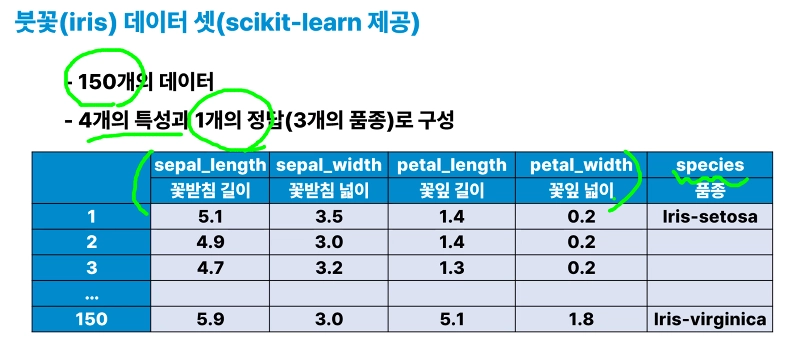

### 목표설정
- KNN 알고리즘을 통해서 붓꽃 품종을 분류해보자
- 머신러닝 모델을 사용하는 방법에 익숙해져보자
- 하이퍼파라미터 튜닝을 진행해보자
- 과대 / 과소 적합 / 일반화 상황을 판단해보자

In [1]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# 사이킷 런에서 데이터 불러오기
from sklearn.datasets import load_iris

In [3]:
# 데이터 객체 만들어주기
iris = load_iris()

In [4]:
# 데이터확인
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [5]:
# 데이터 키값 확인하기
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
# 데이터 역할
# 'data' (필수) : 붓꽃의 정보가 담긴 문제 데이터(X)
# 'target' (필수) : 붓꽃의 품종이 담긴 정답 데이터(y) - 0 / 1 / 2
# 'target_names' (옵션) : 붓꽃 품종의 실제이름
# 'feature_names' (옵션) : 붓꽃 정보의 실제이름
# 'DESCR' (옵션) : 현재 데이터에 대한 설명서 

In [6]:
# 데이터 설명서 확인해보기
print(iris['DESCR'])
# 총 데이터수 150개
# 4개의 특성을 가지고 있다.
# sepal 꽃받침, petal 꽃잎, 단위는 cm
# class -> 3가지 정답 데이터
# =====================================
# 통계데이터
# 결측치 -> 없다
# class -> 3가지 각 클래스가 33.3%로
# =====================================
# 그 아래는 배경설명()

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [7]:
# 데이터 특성 이름을 확인해보기
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [10]:
# 데이터의 가독성을 위해 X데이터를 데이터프레임화 시키기
X = pd.DataFrame(iris['data'], columns = iris['feature_names'])
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [11]:
# 데이터프레임 요약정보 확인해보기
X.info()
# 데이터의형태 -> DataFrame
# 데이터 수 -> 150개
# 컬럼 수 -> 4개 sepal length/ sepal width/ petal length/ petal width
# Non-Null Count (비어있지 않은 갯수) -> 이 갯수와 entries 갯수가 동일하면 결측치없음
# 데이터자료형 -> 실수

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [12]:
# 정답 실제 이름 확인
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [14]:
# 정답 데이터
# 0 / 1 / 2
y = iris['target']
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### 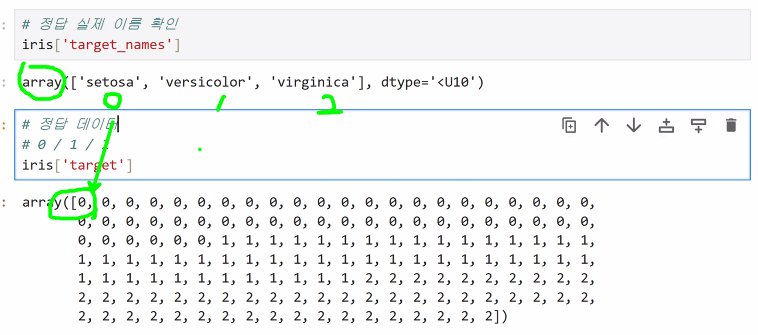

In [15]:
iris['target_names'][y]

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [17]:
# 동일한 데이터끼리 묶여있다
# 훈련용 데이터 : 평가용 데이터 = 7 : 3
 # -> 한쪽으로 쏠려 있는 상황
# 데이터를 섞어서 쪼개야된다.

# 문제점 : 현재 정답데이터는 순차적으로 정리 되어있는 상태
#         슬라이싱으로 단순 분할 하는 경우 데이터가 편중되는 상황이 발생
#         학습 데이터에는 Setosa / versicolor, 평가 데이터에는 virginica만 있는 상황
#         모든 데이터에 균형적인 학습이 일어나지 않는다 -> 모델 성능이 저하

# 해결방안
# sklearn에서 제공하는 데이터 분할 도구를 활용
# train_test_split -> 훈련데이터와 평가데이터를 쪼개는 기능
from sklearn.model_selection import train_test_split

In [18]:
# shuffle = True 섞는 옵션
X_train, X_test, y_train, y_test = train_test_split(X, # 문제 (특성데이터)
                                                    y, # 정답 (예측데이터)
                                                    random_state = 56, # 랜덤방식고정
                                                    train_size = 0.7 # 훈련데이터비중
                                                   )

In [19]:
y_train

array([1, 2, 2, 1, 0, 0, 1, 0, 2, 0, 0, 1, 0, 2, 1, 0, 2, 2, 2, 1, 2, 0,
       2, 0, 1, 0, 0, 1, 0, 1, 1, 2, 1, 2, 1, 2, 0, 2, 2, 0, 2, 0, 1, 2,
       0, 0, 1, 1, 1, 1, 2, 2, 1, 2, 2, 1, 0, 2, 0, 2, 1, 0, 1, 0, 1, 1,
       1, 1, 2, 1, 0, 0, 0, 0, 2, 2, 0, 0, 0, 1, 1, 1, 0, 1, 0, 2, 0, 0,
       0, 1, 1, 2, 0, 0, 2, 2, 1, 1, 2, 0, 1, 2, 2, 2, 1])

In [22]:
# 데이터 분할 확인하기
# 문제와 정답의 갯수가 맞는지 확인
# 변수 순서 X -> y
# (105,1),(45,1) 1은 생략 가능 (1개 열)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((105, 4), (45, 4), (105,), (45,))

### 모델링
- 최근접 이웃 알고리즘 분류모델

In [24]:
# sklearn.neighbors : 이웃을 활용하는 알고리즘 집합소
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# metric 옵션
# 맨해튼 거리공식
# 유클리디언 거리공식
# 2개의 거리공식을 하나로 -> 민코프스키 거리공식
  # P=1(맨해튼) P=2(유클리디언)

# n_jobs 옵션
# 몇개의 core로 계산을 할것인지
# -1 : 전체 core를 다 사용하겠다

In [25]:
# 모델 객체 생성
knn = KNeighborsClassifier()

In [27]:
# 모델 학습 : fit(X_train, y_train)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [28]:
# 예측 진행
pre = knn.predict(X_test)
pre

array([2, 1, 2, 2, 2, 2, 2, 0, 0, 2, 1, 0, 0, 0, 2, 0, 0, 0, 2, 1, 0, 2,
       1, 1, 0, 2, 2, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 2, 2, 0, 1, 2, 2, 2,
       1])

In [29]:
# 예측한 정답의 실제 이름 확인하기
iris['target_names'][pre]

array(['virginica', 'versicolor', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa', 'virginica',
       'versicolor', 'setosa', 'setosa', 'setosa', 'virginica', 'setosa',
       'setosa', 'setosa', 'virginica', 'versicolor', 'setosa',
       'virginica', 'versicolor', 'versicolor', 'setosa', 'virginica',
       'virginica', 'versicolor', 'versicolor', 'versicolor', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa', 'setosa',
       'virginica', 'virginica', 'virginica', 'setosa', 'versicolor',
       'virginica', 'virginica', 'virginica', 'versicolor'], dtype='<U10')

In [30]:
# 성능평가 - 정확도
# sklearn.metrics : 평가도구 모음집
# accuracy_score : 정확도
from sklearn.metrics import accuracy_score

In [31]:
# 채점 진행하기
# accuracy_score(실제 정답, 예측값)
accuracy_score(y_test, pre)

0.9111111111111111

### 하이퍼 파라미터 튜닝

In [36]:
# 하이퍼 파라미터 튜닝을 진행한 경우 
# 그 모델을 다시 학습 시킨후에 예측과 평가를 진행해야한다.

# 주변 이웃값을 7로 설정하고 모델을 만들어보자.
knn2 = KNeighborsClassifier(n_neighbors=7)

In [37]:
# 모델 학습
knn2.fit(X_train, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
# 모델 성능 평가 - score 함수 사용
# score() - X_test먼저 결과를 기억하고 있다가 y_test와 비교
knn2.score(X_test, y_test)

0.9111111111111111

In [ ]:
# 과대적합 / 과소적합 확인해보기
# 반복문을 통해 하이퍼파라미터를 변화 시켜가며 훈련데이터 성능과 평가데이터 성능을 추출
# 그래프를 통해서 과대 / 과소 / 일반화를 확인해보자

In [44]:
# 반복문 지정
# 이웃값은 1부터 100까지 확인

# 빈 리스트 생성
train_score_list = [] # 훈련데이터 성능 저장
test_score_list = [] # 평가데이터 성능 저장

for k in range(1, 101) :
    # 모델 생성
    knn_clf = KNeighborsClassifier(n_neighbors= k)
    # 모델 학습
    knn_clf.fit(X_train, y_train)

    # 훈련데이터 성능 저장하기
    train_score = knn_clf.score(X_train, y_train)
    train_score_list.append(train_score)

    # 평가데이터 성능 저장하기
    test_score = knn_clf.score(X_test, y_test)
    test_score_list.append(test_score)
    

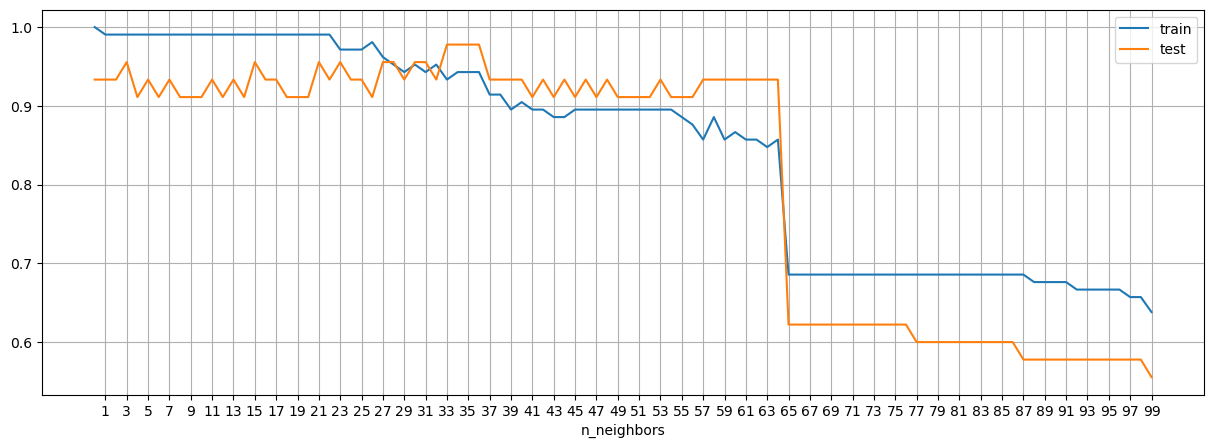

In [45]:
# 시각화를 통해서 훈련점수와 평가점수 그래프화 시키기
plt.figure(figsize=(15,5)) # 그래프 사이즈 조절

plt.plot(train_score_list, label= 'train')
plt.plot(test_score_list, label= 'test')
plt.xticks(range(1, 101, 2)) # X축 눈금값
plt.xlabel('n_neighbors') # X축 이름 붙이기
plt.grid() # 격자무늬 출력
plt.legend() # 범례출력
plt.show()

In [46]:
# 수치로 직접 확인
# 5% = 0.05 (실수로 표현시) --> 기준
train_arr = np.array(train_score_list)
test_arr = np.array(test_score_list)
train_arr - test_arr

array([ 0.06666667,  0.05714286,  0.05714286,  0.03492063,  0.07936508,
        0.05714286,  0.07936508,  0.05714286,  0.07936508,  0.07936508,
        0.07936508,  0.05714286,  0.07936508,  0.05714286,  0.07936508,
        0.03492063,  0.05714286,  0.05714286,  0.07936508,  0.07936508,
        0.07936508,  0.03492063,  0.05714286,  0.01587302,  0.03809524,
        0.03809524,  0.06984127,  0.00634921, -0.0031746 ,  0.00952381,
       -0.0031746 , -0.01269841,  0.01904762, -0.04444444, -0.03492063,
       -0.03492063, -0.03492063, -0.01904762, -0.01904762, -0.03809524,
       -0.02857143, -0.01587302, -0.03809524, -0.02539683, -0.04761905,
       -0.01587302, -0.03809524, -0.01587302, -0.03809524, -0.01587302,
       -0.01587302, -0.01587302, -0.01587302, -0.03809524, -0.01587302,
       -0.02539683, -0.03492063, -0.07619048, -0.04761905, -0.07619048,
       -0.06666667, -0.07619048, -0.07619048, -0.08571429, -0.07619048,
        0.06349206,  0.06349206,  0.06349206,  0.06349206,  0.06